<a href="https://colab.research.google.com/github/Sarkar1166/concrete-strength-regression-analysis/blob/main/concrete_str.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#upload concrete+compressive+strength.zip

In [ ]:
!unzip -o concrete+compressive+strength.zip

Archive:  concrete+compressive+strength.zip
  inflating: Concrete_Data.xls       
  inflating: Concrete_Readme.txt     


In [ ]:
!pip install xlrd

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from scipy import stats

In [ ]:
column_names=[
    'Cement',
    'Blast_Furnace_Slag',
    'Fly_Ash',
    'Water',
    'Superplasticizer',
    'Coarse_Aggregate',
    'Fine_Aggregate',
    'Age',
    'Concrete_compressive_strength'
]
df=pd.read_excel('Concrete_Data.xls',names=column_names)
df.head()

,Cement,Blast_Furnace_Slag,Fly_Ash,Water,Superplasticizer,Coarse_Aggregate,Fine_Aggregate,Age,Concrete_compressive_strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


Plotting Histogram, PDF,and CDF

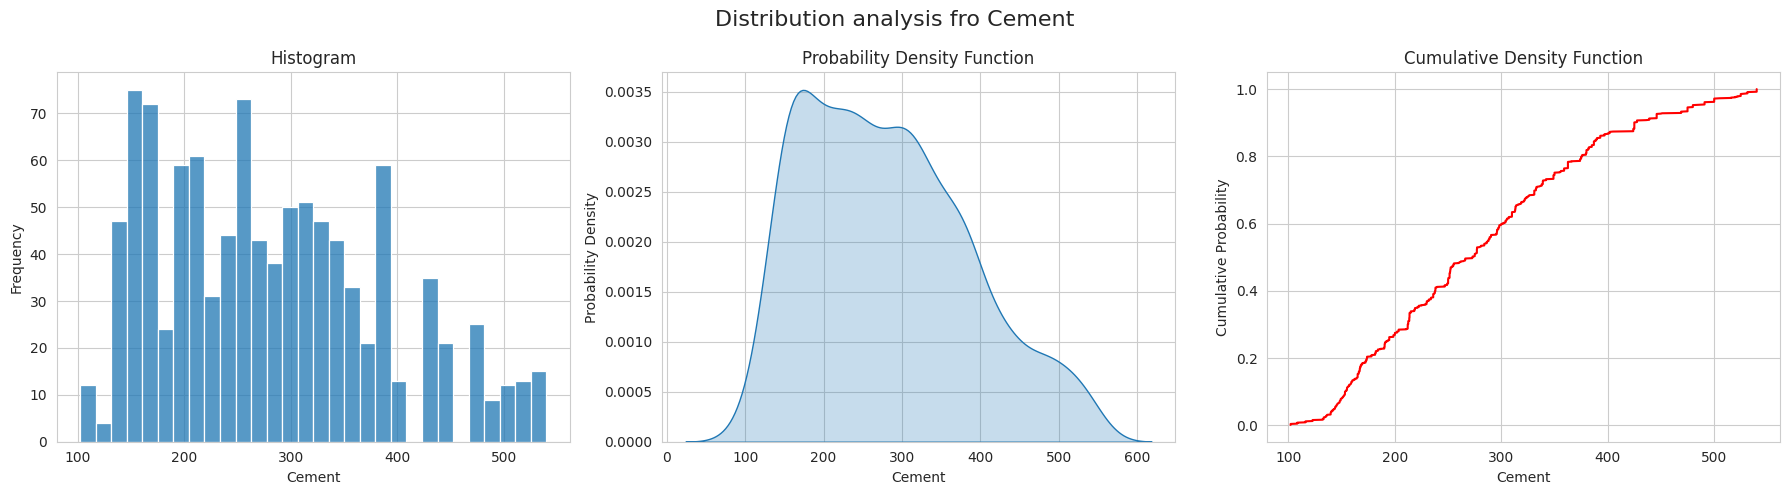

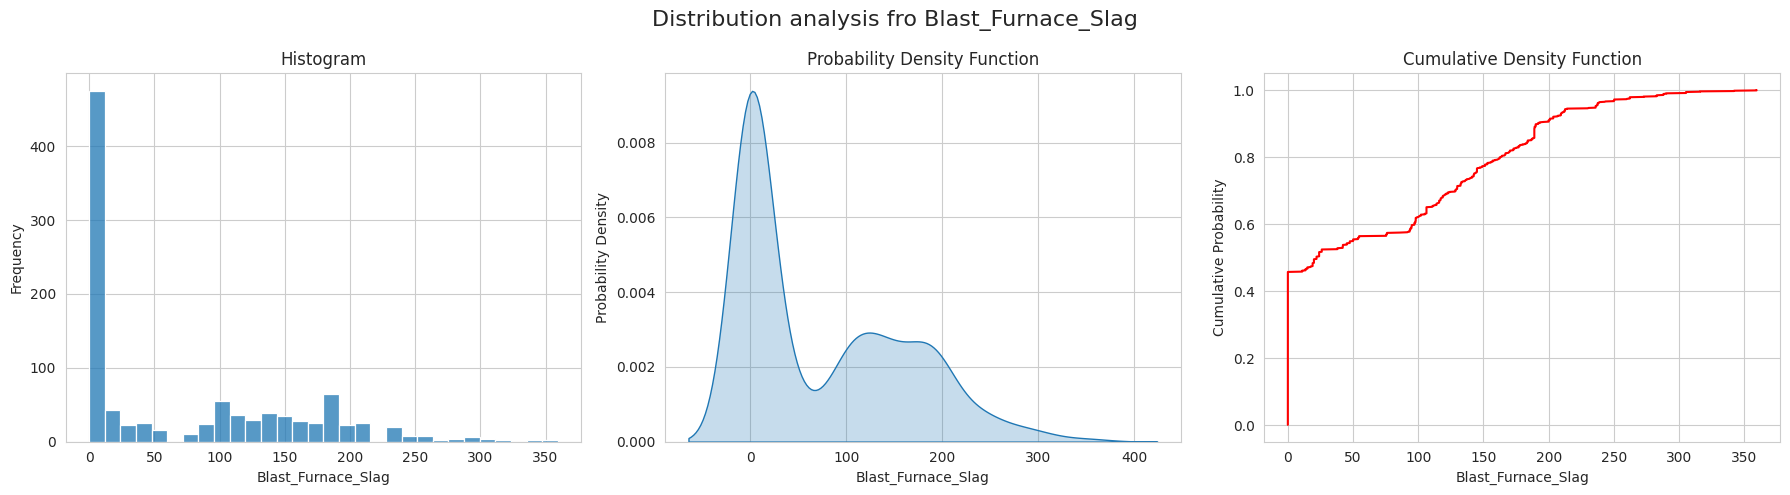

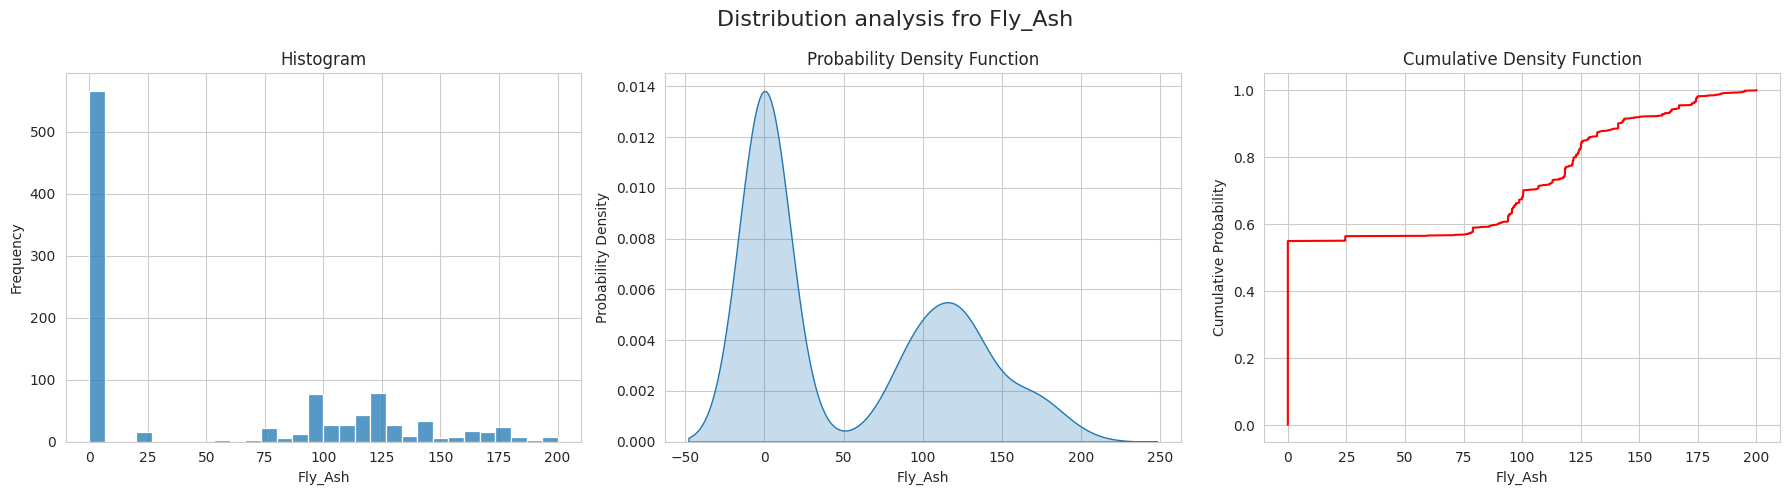

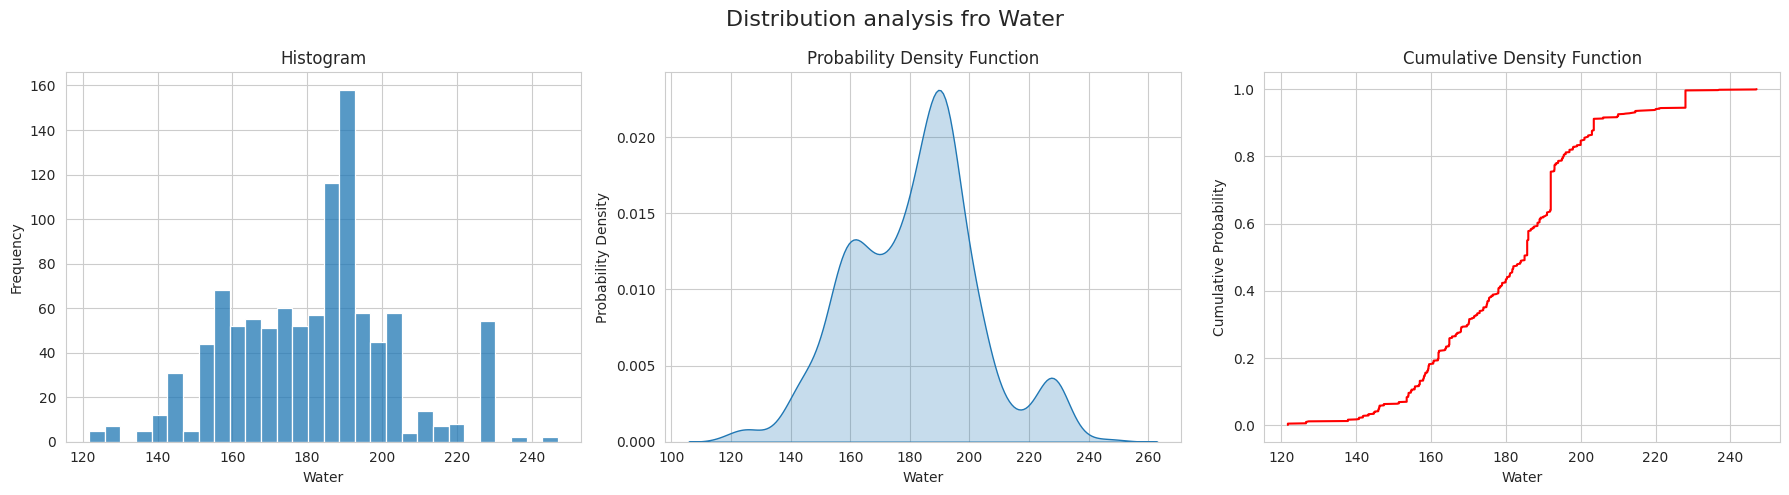

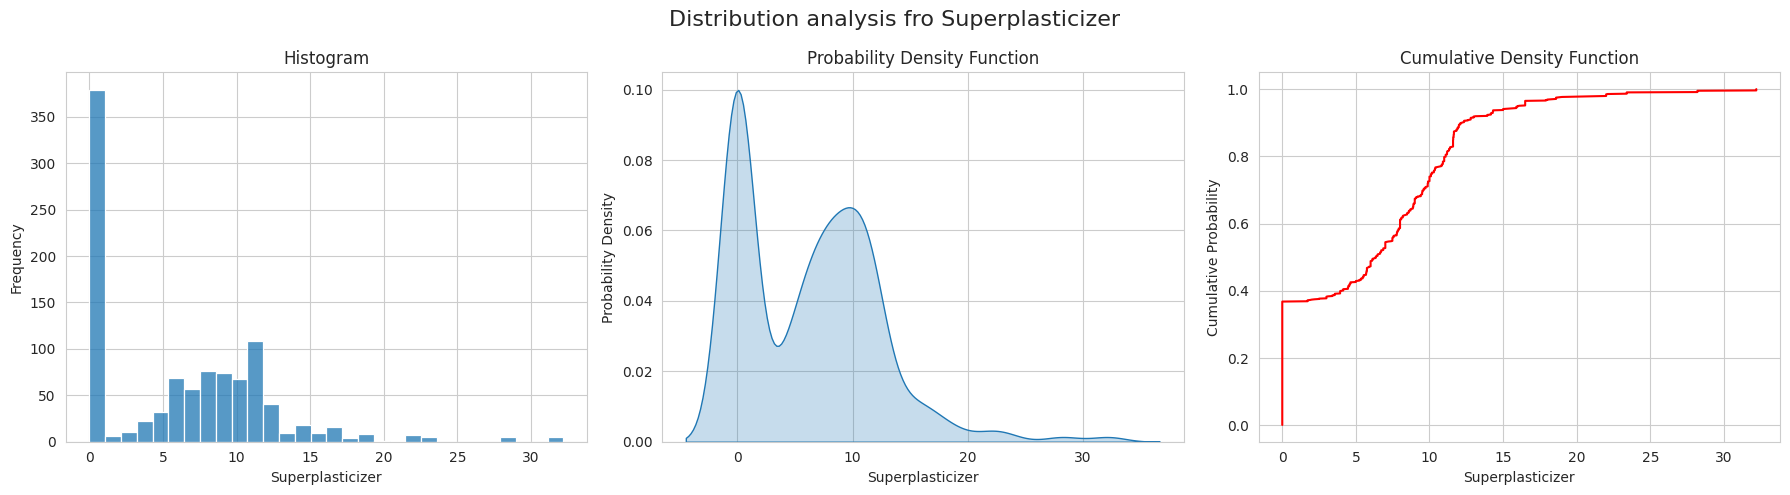

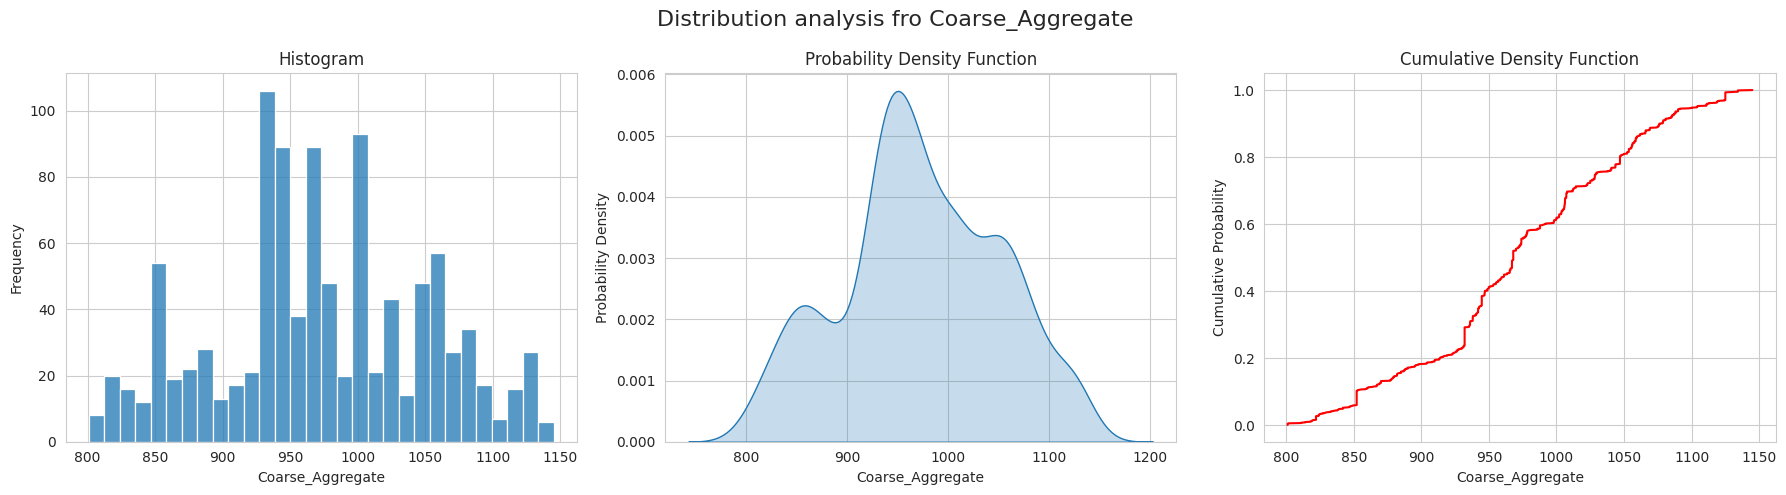

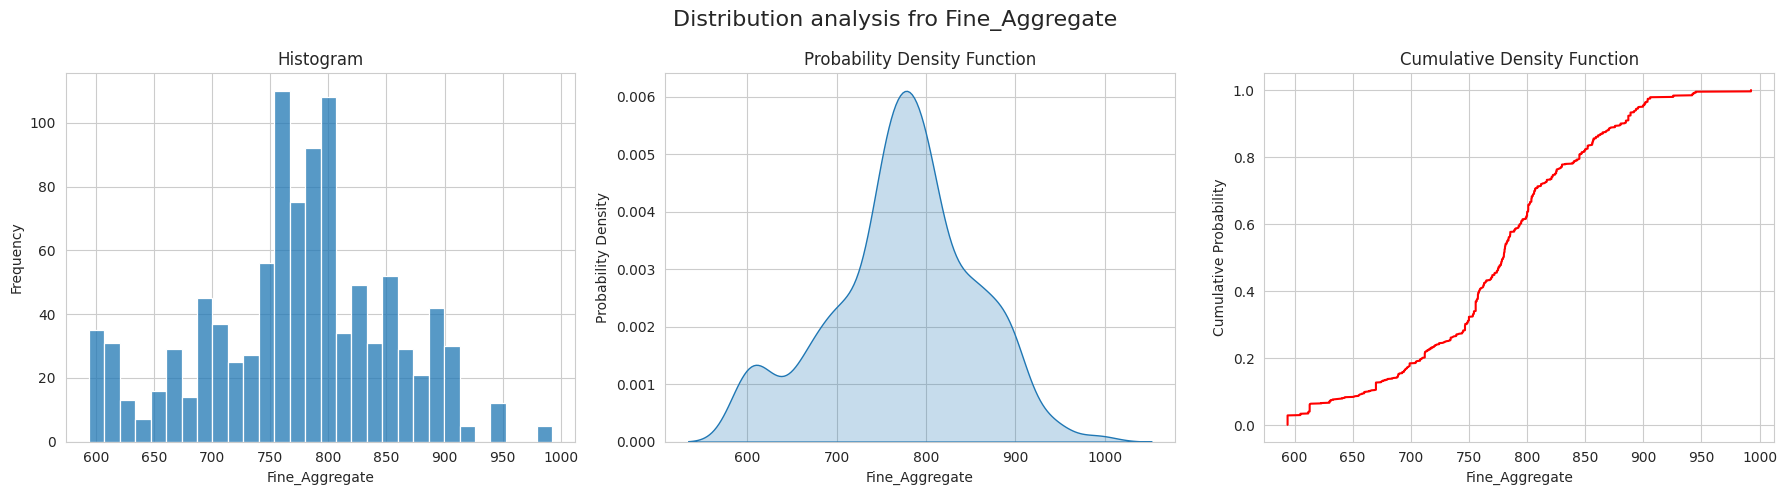

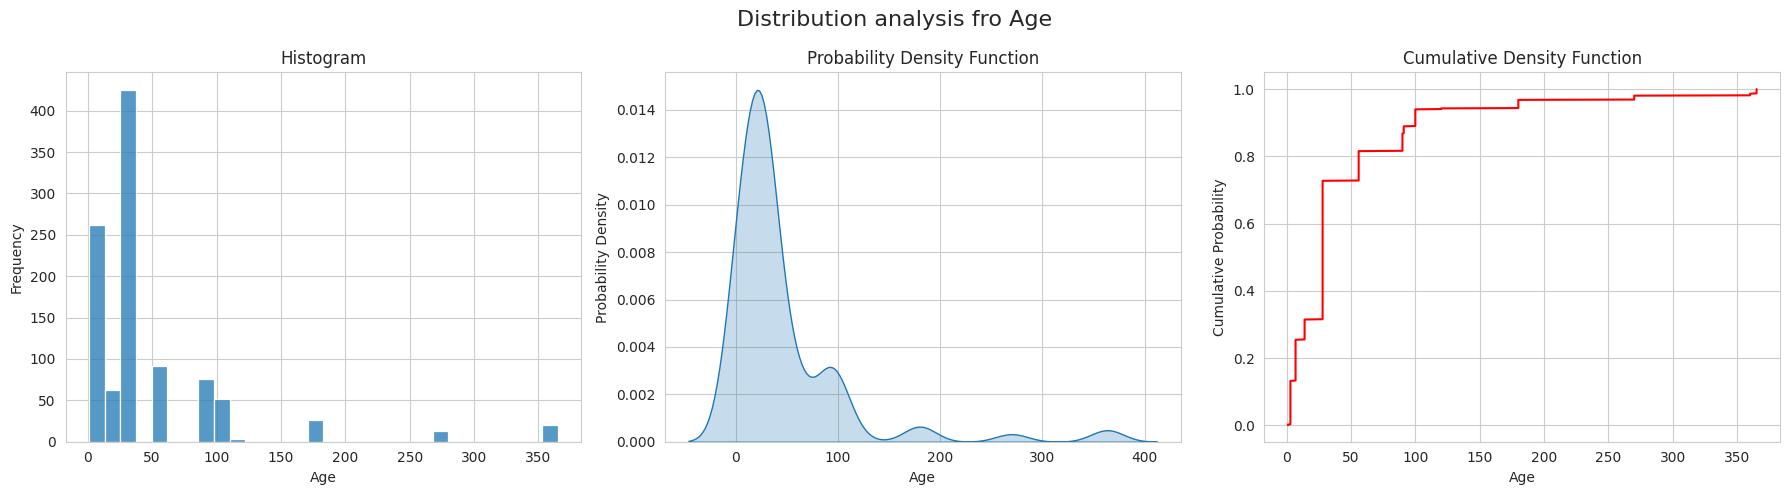

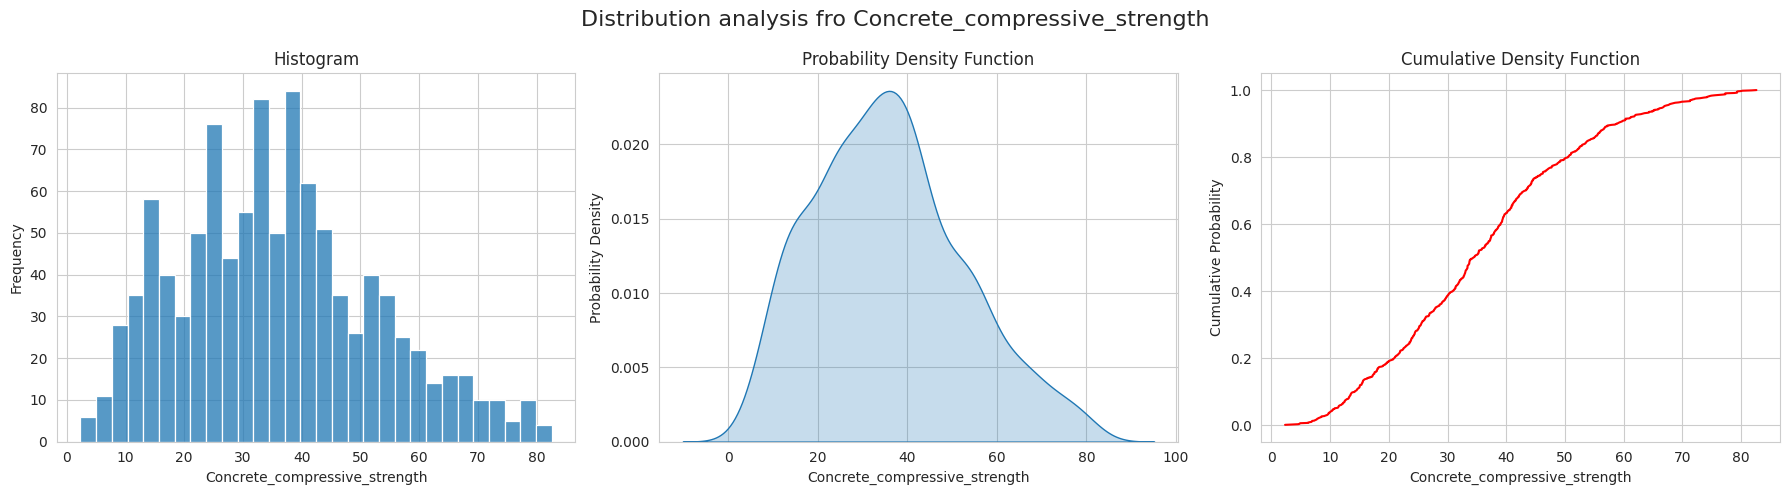

In [ ]:
#set plot style
sns.set_style('whitegrid')

#Relating each axis to columns
for col in df.columns:
  fig, ax= plt.subplots(1,3, figsize=(18,5))
  fig.suptitle(f'Distribution analysis fro {col}',fontsize=16)

  #Histogram
  sns.histplot(df[col],ax=ax[0],bins=30, kde=False)
  ax[0].set_xlabel(col)
  ax[0].set_ylabel('Frequency')
  ax[0].set_title('Histogram')

  #Probability density Function
  sns.kdeplot(df[col],ax=ax[1],fill=True)
  ax[1].set_xlabel(col)
  ax[1].set_ylabel('Probability Density')
  ax[1].set_title('Probability Density Function')

  #Cumulative Density Function
  #Sort data and calculate cumulative probab
  sorted_data=np.sort(df[col])
  cum_prob=np.arange(1,len(sorted_data)+1)/len(sorted_data)
  ax[2].plot(sorted_data,cum_prob,color='red')
  ax[2].set_xlabel(col)
  ax[2].set_ylabel('Cumulative Probability')
  ax[2].set_title('Cumulative Density Function')

  plt.tight_layout()
  plt.show()

a) Compute and comment on their statistical parameters (mean, variance, skewness, kurtosis).


In [ ]:
#Calculating stats
stats_df=pd.DataFrame({
    'Mean':df.mean(),
    'Variance':df.var(),
    'Standard Deviation':df.std(),
    'Skewness':df.skew(),
    'Kurtosis':df.kurtosis()
    #Normal Kurtiosis=0
})
stats_df

,Mean,Variance,Standard Deviation,Skewness,Kurtosis
Cement,281.165631,10921.742654,104.507142,0.509517,-0.520663
Blast_Furnace_Slag,73.895485,7444.083725,86.279104,0.800737,-0.508139
Fly_Ash,54.187136,4095.548093,63.996469,0.537445,-1.328505
Water,181.566359,456.060245,21.355567,0.074324,0.122676
Superplasticizer,6.203112,35.682602,5.973492,0.908113,1.413186
Coarse_Aggregate,972.918592,6045.656228,77.753818,-0.040206,-0.599001
Fine_Aggregate,773.578883,6428.099159,80.175427,-0.252979,-0.102165
Age,45.662136,3990.437729,63.169912,3.269177,12.168989
Concrete_compressive_strength,35.817836,279.079717,16.705679,0.416922,-0.313844


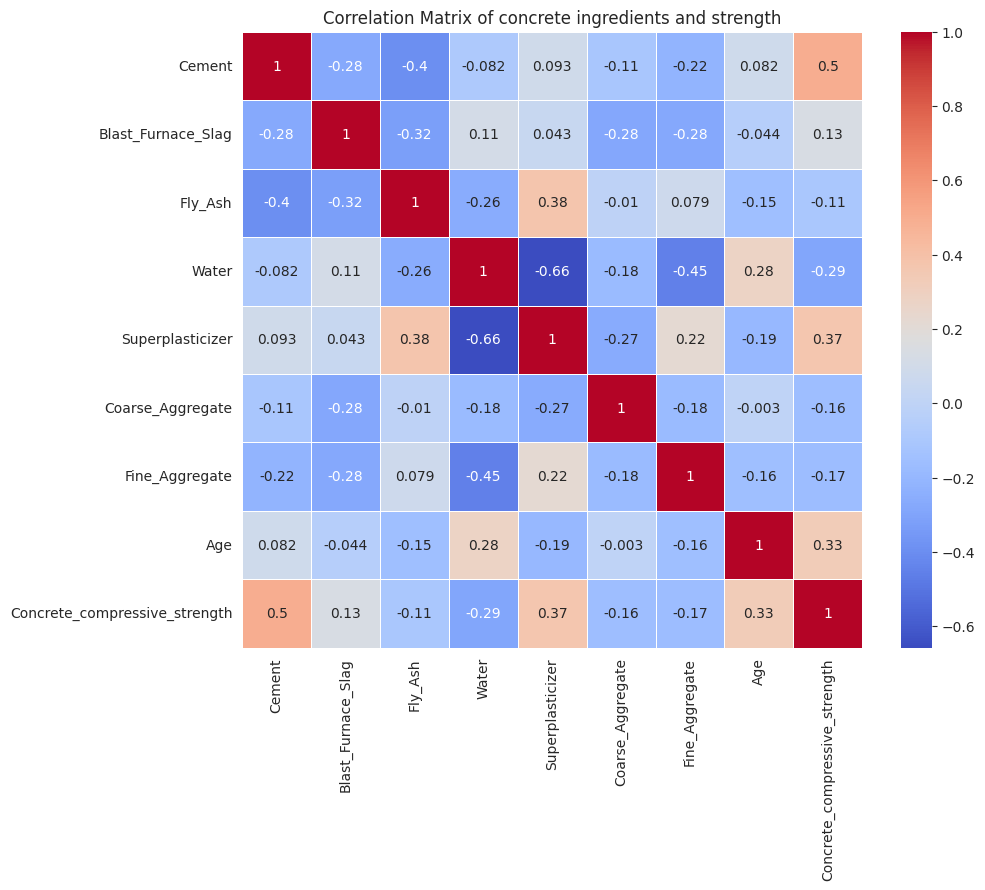

In [ ]:
#Calculate correlation matrix
corr_matrix=df.corr()

#plot the heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',linewidths=0.5)
plt.title('Correlation Matrix of concrete ingredients and strength')
plt.show()

 Estimate the statistical parameters of compressive strength (mean, variance, standard deviation) and report them along with their 95% confidence intervals.

In [ ]:
strength=df['Concrete_compressive_strength']

strength_mean=strength.mean()
strength_var=strength.var()
strength_std=strength.std()

print(f'Mean: {strength_mean}')
print(f'Variance: {strength_var}')
print(f'Standard Deviation: {strength_std}')

#calculating 95% CI
#We are using t-distrubition as population std is unknown, chi dist fro variance
n=len(strength)
ci_mean=stats.t.interval(0.95,n-1,loc=strength_mean,scale=stats.sem(strength))
ci_var=stats.chi2.interval(0.95,n-1,loc=strength_var,scale=stats.sem(strength)**2)
ci_std=stats.t.interval(0.95,n-1,loc=strength_std,scale=stats.sem(strength))

print(f"Analysis for Concrete Compressive Strength:")
print(f"---------------------------------------------")
print(f"Mean: {strength_mean:.2f} MPa")
print(f"Variance: {strength_var:.2f} MPa^2")
print(f"Standard Deviation: {strength_std:.2f} MPa")
print(f"95% Confidence Interval for the Mean: ({ci_mean[0]:.2f} MPa, {ci_mean[1]:.2f} MPa)")
print(f"95% Confidence Interval for the Variance: ({ci_var[0]:.2f} MPa^2, {ci_var[1]:.2f} MPa^2)")
print(f"95% Confidence Interval for the Standard Deviation: ({ci_std[0]:.2f} MPa, {ci_std[1]:.2f} MPa)")

Mean: 35.8178358261136
Variance: 279.0797166936163
Standard Deviation: 16.70567917486794
Analysis for Concrete Compressive Strength:
---------------------------------------------
Mean: 35.82 MPa
Variance: 279.08 MPa^2
Standard Deviation: 16.71 MPa
95% Confidence Interval for the Mean: (34.80 MPa, 36.84 MPa)
95% Confidence Interval for the Variance: (534.31 MPa^2, 582.49 MPa^2)
95% Confidence Interval for the Standard Deviation: (15.68 MPa, 17.73 MPa)


For compressive strength, test whether the data follows a normal distribution using:
Probability plots (Q–Q plots)
Normality tests (e.g: Kolmogorov–Smirnov)
Comment on whether compressive strength data can reasonably be modeled as a normal distribution.

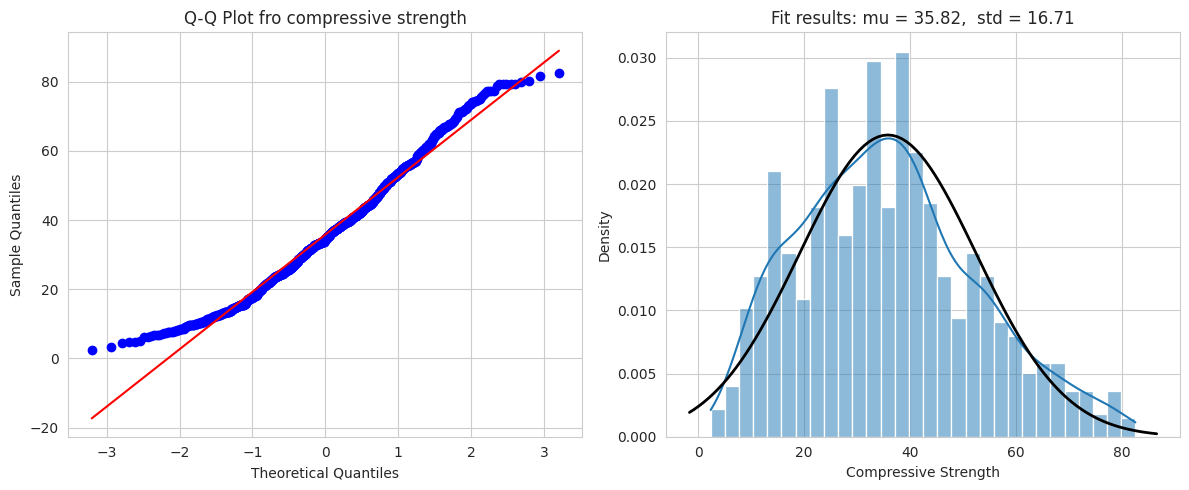

In [ ]:
#1.Probability Plots(Q-Q)
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
stats.probplot(strength,dist='norm',plot=plt)
plt.title('Q-Q Plot fro compressive strength')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')

# Add a histogram with a normal curve overlay for visual comparison
plt.subplot(1,2,2)
sns.histplot(strength,kde=True,bins=30, stat='density')
plt.title('Histogram fro compressive strength')
plt.xlabel('Compressive Strength')
plt.ylabel('Density')

#Plot a perfect normal distribution over it
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, strength_mean, strength_std)
plt.plot(x, p, 'k', linewidth=2)
title = "Fit results: mu = %.2f,  std = %.2f" % (strength_mean, strength_std)
plt.title(title)

plt.tight_layout()
plt.show()

In [ ]:
ks_stat, ks_p = stats.kstest(strength, 'norm', args=(strength.mean(), strength.std()))
print(f"\nKolmogorov-Smirnov Test:")
print(f"Statistic: {ks_stat:.4f}, p-value: {ks_p:.4f}")



Kolmogorov-Smirnov Test:
Statistic: 0.0413, p-value: 0.0579


In [ ]:
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error

# --- a) Perform a regression analysis ---

# 1. Define predictor (X) and target (y) variables
# The problem is a regression problem with 8 input variables and 1 output variable [cite: 7]
X = df.drop('Concrete_compressive_strength', axis=1)
y = df['Concrete_compressive_strength']

# 2. Add a constant (intercept) to the predictor variables for the statsmodels library
X = sm.add_constant(X)

# 3. Fit the Ordinary Least Squares (OLS) linear regression model
model = sm.OLS(y, X)
results = model.fit()

# 4. Print the detailed summary of the regression results
print("\n--- Regression Analysis Results ---")
print(results.summary())


--- Regression Analysis Results ---
                                  OLS Regression Results                                 
Dep. Variable:     Concrete_compressive_strength   R-squared:                       0.615
Model:                                       OLS   Adj. R-squared:                  0.612
Method:                            Least Squares   F-statistic:                     204.3
Date:                           Mon, 29 Sep 2025   Prob (F-statistic):          6.76e-206
Time:                                   20:49:06   Log-Likelihood:                -3869.0
No. Observations:                           1030   AIC:                             7756.
Df Residuals:                               1021   BIC:                             7800.
Df Model:                                      8                                         
Covariance Type:                       nonrobust                                         
                         coef    std err          t      P>|t| 